### Look at natural variation across topsoils

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

KO = 'K00370'
annotation = pd.read_csv(f'../data/topsoil/dmndv0_s_{KO}_rep_q_topsoil_e_1e-5_pid_50.tsv', sep = '\t', header = None).values
sequences = pd
print(annotation.shape)

for i in range(10):
    print(annotation[i])
    


(175185, 12)
['FS101__C6797_L=452;_1' 'nfs:OIE67_54775' 56.0 50 16 1 4 47 291 340
 1.3e-08 53.5]
['FS101__C6797_L=452;_1' 'rub:GBA63_10615' 55.3 47 15 1 7 47 295 341
 1.4e-07 50.1]
['FS101__C6797_L=452;_1' 'gew:MF406_16270' 51.1 47 17 1 7 47 322 368
 1.8e-07 49.7]
['FS101__C6797_L=452;_1' 'asd:AS9A_2092' 53.2 47 16 1 7 47 308 354 2.4e-07
 49.3]
['FS101__C6797_L=452;_1' 'arev:RVR_4929' 50.0 50 19 1 4 47 332 381 4.1e-07
 48.5]
['FS101__C6797_L=452;_1' 'rub:GBA63_19395' 53.2 47 16 1 7 47 295 341
 4.1e-07 48.5]
['FS101__C6797_L=452;_1' 'sia:M1425_0828' 51.1 47 17 1 7 47 273 319
 4.1e-07 48.5]
['FS101__C6797_L=452;_1' 'sspo:DDQ41_29520' 51.0 49 18 1 5 47 304 352
 5.3e-07 48.1]
['FS101__C6797_L=452;_1' 'cef:CE1296' 51.1 47 17 1 7 47 301 347 7e-07 47.8]
['FS101__C6797_L=452;_1' 'rsua:LQF12_10045' 51.1 47 17 1 7 47 313 359
 9.1e-07 47.4]


In [ ]:
import gzip

# Read annotations and get unique sequence IDs
annotations = pd.read_csv('../data/topsoil/dmndv0_s_K00370_rep_q_topsoil_e_1e-5_pid_50.tsv', 
                         sep='\t', header=None)
unique_annotations = annotations.drop_duplicates(subset=0)  # Keep first occurrence per sequence ID
unique_ids = set(unique_annotations[0])

# Write unique annotations to file
unique_annotations.to_csv('../data/topsoil/K00370_unique_annotations.tsv', sep='\t', header=False, index=False)

# Filter FASTA sequences
with gzip.open('../data/raw_data/topsoil/compl.incompl.95.prot.faa.gz', 'rt') as f_in, \
     open('../data/topsoil/K00370_annotated_sequences.faa', 'w') as f_out:
    
    print_sequence = False
    current_id = ""
    
    for line in f_in:
        if line.startswith('>'):
            # Extract sequence ID (remove '>' and any additional info)
            current_id = line[1:].split()[0]
            print_sequence = current_id in unique_ids
        
        if print_sequence:
            f_out.write(line)

In [ ]:

def filter_fasta_by_length(input_fasta, output_fasta, min_length=1000):
    """
    Filter FASTA file by sequence length
    """
    sequences_kept = 0
    total_sequences = 0
    
    with open(input_fasta, 'r') as f_in, open(output_fasta, 'w') as f_out:
        current_header = ""
        current_sequence = ""
        
        for line in f_in:
            if line.startswith('>'):
                # Process the previous sequence before starting new one
                if current_header and len(current_sequence) >= min_length:
                    f_out.write(current_header + current_sequence)
                    sequences_kept += 1
                
                # Start new sequence
                current_header = line
                current_sequence = ""
                total_sequences += 1
            else:
                current_sequence += line
        
        # Don't forget the last sequence
        if current_header and len(current_sequence) >= min_length:
            f_out.write(current_header + current_sequence)
            sequences_kept += 1
    
    print(f"Total sequences: {total_sequences}")
    print(f"Sequences kept (length >= {min_length}): {sequences_kept}")
    print(f"Filtered FASTA saved to: {output_fasta}")


filter_fasta_by_length('../data/topsoil/K00370_annotated_sequences.faa', '../data/topsoil/K00370_sequences_min1000aa.faa', 1000)

In [11]:
from Bio import SeqIO
from Bio import pairwise2


# Load sequences
sequences = {}
for record in SeqIO.parse("../data/topsoil/K00370_sequences_min1000aa.faa", "fasta"):
    sequences[record.id] = str(record.seq)

seq_ids = list(sequences.keys())
n_seqs = len(seq_ids)

# Create alignment matrix
alignment_matrix = np.zeros((n_seqs, n_seqs))

print(f"Creating {n_seqs}x{n_seqs} alignment matrix...")

for i in range(n_seqs):
    for j in range(i, n_seqs):  # Only compute upper triangle + diagonal
        if i == j:
            # Self-alignment: score = sequence length
            alignment_matrix[i, j] = len(sequences[seq_ids[i]])
        else:
            # Pairwise alignment
            alignments = pairwise2.align.globalxx(sequences[seq_ids[i]], sequences[seq_ids[j]])
            alignment_matrix[i, j] = alignments[0][2]  # Get the score
            alignment_matrix[j, i] = alignment_matrix[i, j]  # Make symmetric

# Save as CSV with sequence IDs as row/column headers
matrix_df = pd.DataFrame(alignment_matrix, index=seq_ids, columns=seq_ids)
matrix_df.to_csv("../data/topsoil/alignment_matrix.tsv")

print(f"Alignment matrix saved to 'alignment_matrix.tsv'")
print(f"Matrix shape: {alignment_matrix.shape}")

Creating 120x120 alignment matrix...
Alignment matrix saved to 'alignment_matrix.tsv'
Matrix shape: (120, 120)


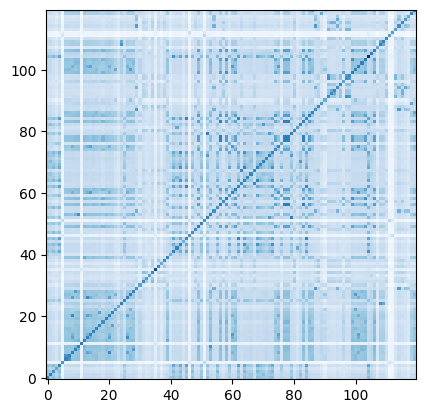

In [12]:
plt.imshow(alignment_matrix, cmap = 'Blues', origin = 'lower')
np.savetxt('../data/topsoil/alignment_matrix_min1000.tsv', alignment_matrix, delimiter='\t', fmt='%0.0f')

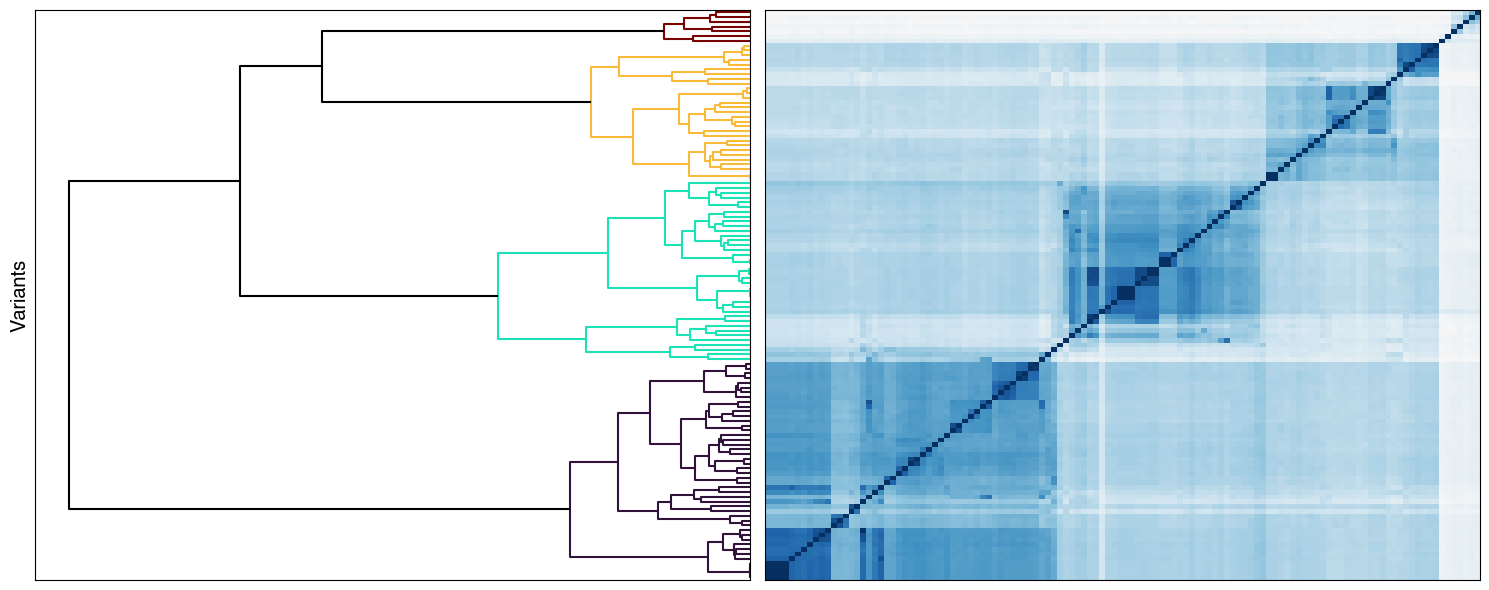

In [18]:
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, optimal_leaf_ordering
from scipy.cluster import hierarchy
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist
from matplotlib.colors import to_hex
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler = MinMaxScaler()

alignment_matrix = pd.read_csv('../data/topsoil/alignment_matrix_min1000.tsv', sep = '\t', header = None).values

alignment_matrix = scaler.fit_transform(alignment_matrix)

Z = linkage(alignment_matrix, method='ward', metric='euclidean')
Z_optimal = optimal_leaf_ordering(Z, pdist(alignment_matrix, metric='euclidean'))

n_clusters = 4
clusters = fcluster(Z_optimal, t=n_clusters, criterion='maxclust')

dendro = dendrogram(Z_optimal, no_plot=True)
leaf_indices = dendro['leaves']

idx_to_cluster = {i: clusters[i] for i in range(len(clusters))}


next_node = len(clusters)
node_to_cluster = {}

for i, (left, right, _, _) in enumerate(Z_optimal):
    left, right = int(left), int(right)
    left_cluster = idx_to_cluster.get(left, node_to_cluster.get(left, -1))
    right_cluster = idx_to_cluster.get(right, node_to_cluster.get(right, -1))
    if left_cluster == right_cluster and left_cluster != -1:
        node_to_cluster[next_node] = left_cluster
    next_node += 1
    
#cluster_colors = ['#1f77b4', "#9729E0", "#610a70", "#210bcb"]
cmap = plt.cm.turbo # Or any other colormap (e.g., 'viridis', 'plasma')
cluster_colors = [to_hex(cmap(i)) for i in np.linspace(0, 1, n_clusters)]

def color_func(link_idx):
    cluster_id = node_to_cluster.get(link_idx, -1)
    if cluster_id != -1 and cluster_id <= len(cluster_colors):
        return cluster_colors[cluster_id - 1]
    return "#000000"  # default color for unclustered links


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1, 1]})

dendrogram(Z_optimal,
           orientation='left',
           ax=ax1,
           color_threshold=max(Z_optimal[-n_clusters+1, 2], 0.1),
           link_color_func=color_func,
           above_threshold_color='k')

ax1.set_title('')
ax1.set_xlabel('')
ax1.set_ylabel('Variants', fontname='Helvetica', fontsize = 'x-large')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(left=False, bottom=False)

data = np.array(alignment_matrix)

rearranged_data = data[leaf_indices]
rearranged_data = rearranged_data[:, leaf_indices]

im = ax2.imshow(rearranged_data, aspect='auto', cmap='RdBu',
                interpolation='nearest', origin='lower', vmin = -1, vmax = 1)
#plt.colorbar(im, ax=ax2)


boundaries = np.where(np.diff(clusters[leaf_indices]))[0]
# for b in boundaries:
#     ax2.axhline(b + 0.5, color='black', linestyle='--')
    
# ax2.axvline(19.5, color='black', linestyle='--')
# ax2.axvline(129.5, color='black', linestyle='--')
# ax2.axvline(186.5, color='black', linestyle='--')
ax2.set_xticks([])

ax2.set_yticks([])
plt.tight_layout()

    
plt.show()
    

### Next, align each of these 125 with each of the 57

In [19]:
import numpy as np
import pandas as pd
from Bio import SeqIO
from Bio import pairwise2
from tqdm import tqdm

# Load topsoil sequences
sequences = {}
for record in SeqIO.parse("../data/topsoil/K00370_sequences_min1000aa.faa", "fasta"): #125 sequences
    sequences[record.id] = str(record.seq)

seq_ids = list(sequences.keys())
n_seqs = len(seq_ids)

# Load original sequences
sequences_old = {}
for record in SeqIO.parse("../out/aaseqs/K00370/long_complete_aa_seqs.fasta", "fasta"): #57 sequences
    sequences_old[record.id] = str(record.seq)

seq_ids_old = list(sequences_old.keys())
n_seqs_old = len(seq_ids_old)

# Create alignment matrix
alignment = np.zeros((n_seqs, n_seqs_old))

print(f"Creating {n_seqs}x{n_seqs_old} alignment matrix...")

for i in tqdm(range(n_seqs)):
    for j in range(n_seqs_old):
        # Pairwise alignment between sequence i from first set and sequence j from second set
        alignments = pairwise2.align.globalxx(sequences[seq_ids[i]], sequences_old[seq_ids_old[j]])
        alignment[i, j] = alignments[0][2]  # Get the score

# Save as CSV with sequence IDs as row/column headers
matrix_df = pd.DataFrame(alignment, index=seq_ids, columns=seq_ids_old)
matrix_df.to_csv("../data/topsoil/alignment_oldnew.tsv", sep='\t')

print(f"Alignment matrix saved to 'alignment_oldnew.tsv'")
print(f"Matrix shape: {alignment.shape}")

Creating 120x57 alignment matrix...


100%|██████████| 120/120 [07:21<00:00,  3.68s/it]

Alignment matrix saved to 'alignment_oldnew.tsv'
Matrix shape: (120, 57)


[3. 1. 1. 4. 3. 3. 4. 4. 1. 2. 1. 4. 1. 2. 1. 1. 4. 1. 4. 1. 3. 4. 1. 4.
 2. 3. 3. 3. 4. 2. 3. 1. 1. 4. 4. 1. 1. 1. 3. 3. 4. 1. 1. 3. 4. 4. 3. 3.
 3. 4. 4. 4. 4. 4. 4. 1. 4.]


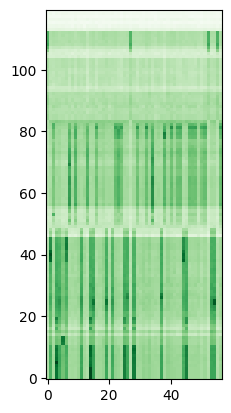

In [20]:
plt.imshow(alignment[leaf_indices], origin = 'lower', cmap = 'Greens')

groups = pd.read_csv("../out/groups/assignments_K00370_v2.tsv", sep = '\t', header = None ).values

group_idx = np.zeros(len(groups))
for i in range(len(groups)):
    group_idx[i] = groups[i][0][-1]
print(group_idx)

Original alignment shape: (120, 57)
Collapsed alignment shape: (120, 4)
Scaled collapsed alignment shape: (120, 4)


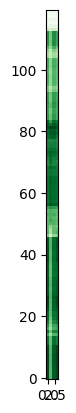

In [21]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import minmax_scale


# Create the collapsed matrix with 4 columns
alignment_collapse = np.zeros((alignment.shape[0], 4))

# Sum alignment scores for each group
for group_num in range(1, 5):
    # Get indices where group_idx equals the current group number
    group_mask = (group_idx == group_num)
    
    # Sum the alignment scores for this group across columns
    alignment_collapse[:, group_num-1] = np.sum(alignment[:, group_mask], axis=1)

# Min-max scale each column independently
alignment_collapse = minmax_scale(alignment_collapse, axis=0)

# If you want to keep it as a DataFrame with meaningful column names:
alignment_collapse_df = pd.DataFrame(
    alignment_collapse, 
    columns=[f'Group_{i}' for i in range(1, 5)]
)

plt.imshow(alignment_collapse[leaf_indices], origin = 'lower', cmap = 'Greens')

print(f"Original alignment shape: {alignment.shape}")
print(f"Collapsed alignment shape: {alignment_collapse.shape}")
print(f"Scaled collapsed alignment shape: {alignment_collapse.shape}")

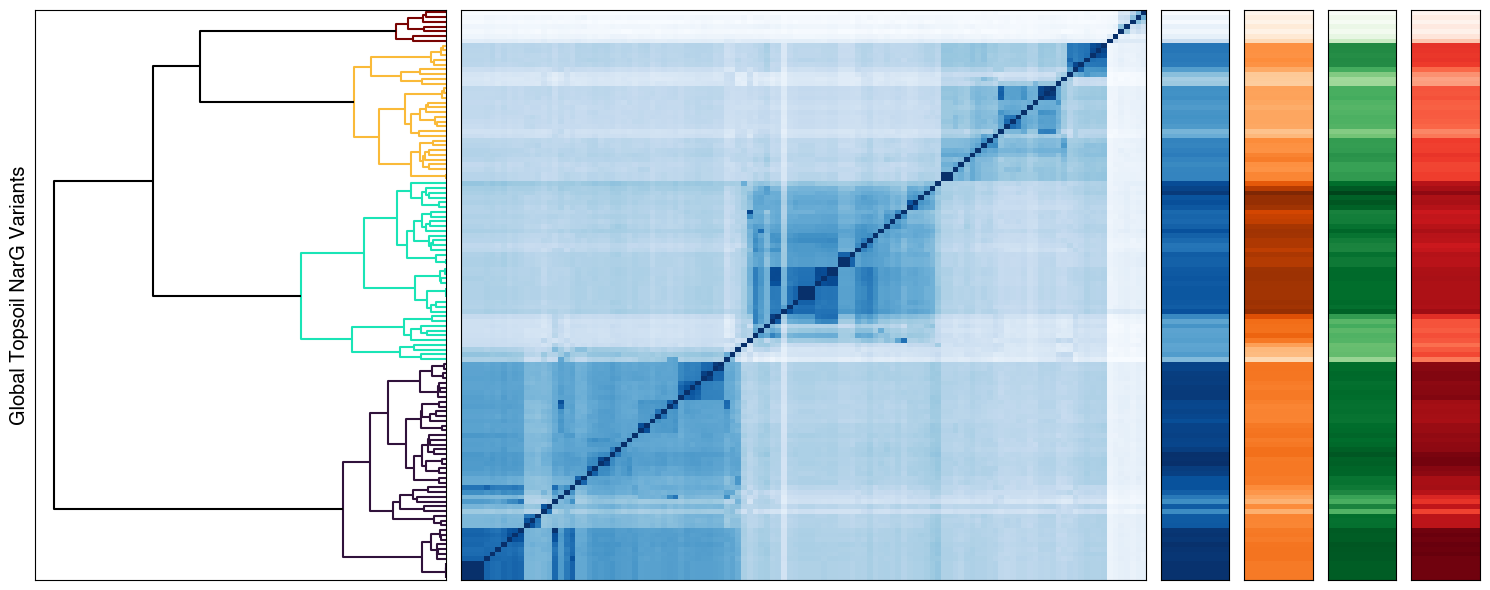

In [22]:
fig = plt.figure(figsize=(15, 6))
gs = fig.add_gridspec(1, 6, width_ratios=[0.3, 0.5, 0.05, 0.05, 0.05, 0.05])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3_1 = fig.add_subplot(gs[2])
ax3_2 = fig.add_subplot(gs[3])
ax3_3 = fig.add_subplot(gs[4])
ax3_4 = fig.add_subplot(gs[5])

dendrogram(Z_optimal,
           orientation='left',
           ax=ax1,
           color_threshold=max(Z_optimal[-n_clusters+1, 2], 0.1),
           link_color_func=color_func,
           above_threshold_color='k')

ax1.set_title('')
ax1.set_xlabel('')
ax1.set_ylabel('Global Topsoil NarG Variants', fontname='Helvetica', fontsize='x-large')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(left=False, bottom=False)

data = np.array(alignment_matrix)
rearranged_data = data[leaf_indices]
rearranged_data = rearranged_data[:, leaf_indices]

im = ax2.imshow(rearranged_data, aspect='auto', cmap='Blues',
                interpolation='nearest', origin='lower', vmin=0, vmax=1)

ax2.set_xticks([])
ax2.set_yticks([])

# Plot each column as separate subplot with different colors
cmaps = ['Blues', 'Oranges', 'Greens', 'Reds']
axes = [ax3_1, ax3_2, ax3_3, ax3_4]

for i, (ax, cmap) in enumerate(zip(axes, cmaps)):
    im_sub = ax.imshow(alignment_collapse[leaf_indices][:, i:i+1], aspect='auto', cmap=cmap, 
                       origin='lower', vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

In [28]:
print(seq_ids)
# S1 = pd.read_csv('../data/topsoil/S1.csv')
sam_ids = []
for seq in seq_ids:
    sam = seq.split('_')[0]
    sam_ids.append(sam)

sam_ids = list(set(sam_ids))
print(len(sam_ids))   
for i in range(len(sam_ids)):
    print(sam_ids[i])



['FS177__C100_L=13996;_13', 'FS177__C227_L=8378;_4', 'S243__C14230_L=3895=_1', 'S244__C20752_L=6357=_4', 'S244__C14022_L=7807=_2', 'S244__C3835_L=14983=_4', 'S285__C2915_L=28090=_15', 'S285__C4850_L=20397=_7', 'S285__C1026_L=50631=_11', 'S285__C2951_L=27898=_18', 'S285__C140_L=130936=_21', 'S285__C27_L=253622=_99', 'S285__C297_L=94849=_52', 'S285__C9455_L=12507=_6', 'S285__C12129_L=10232=_6', 'S285__C709_L=62533=_5', 'S285__C1175_L=47089=_33', 'S285__C901_L=54752=_40', 'S285__C38247_L=3632=_1', 'S285__C22669_L=5968=_2', 'S285__C25616_L=5334=_2', 'S285__C12236_L=10165=_4', 'S285__C41489_L=3358=_1', 'S285__C43883_L=3182=_2', 'S285__C101_L=151890=_114', 'S285__C1220_L=46161=_31', 'S285__C3581_L=24847=_5', 'S285__C1_L=650655=_455', 'S285__C577_L=68402=_35', 'S285__C10207_L=11748=_9', 'S285__C20267_L=6616=_1', 'S305__C115_L=12654=_3', 'S305__C75_L=14806=_16', 'S306__C20376_L=4948=_3', 'S306__C635_L=38745=_23', 'S306__C4576_L=12404=_7', 'S306__C1392_L=25270=_20', 'S306__C635_L=38745=_29', 'S